# 00: Exploration & Sanity Checks

**Purpose**: Read-only exploratory notebook for data sanity checks and geographic intuition.

**Goals**:
1. Load raw data (read-only): tracts, jobs, demographics, transit stops
2. Perform basic sanity checks: counts, missing data, CRS consistency, bounding boxes
3. Create simple static maps: tracts, jobs choropleth, transit stops overlay
4. Build intuition about LA's spatial structure

**⚠️ MUST NOT include**:
- ❌ No accessibility calculations
- ❌ No travel time logic
- ❌ No optimization
- ❌ No corridor ideas
- ❌ No metrics or analysis

**Checkpoint**: "Yes, the data makes sense spatially, and nothing looks broken."


In [43]:
import sys
from pathlib import Path

ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / "src"))

import config
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_palette("husl")

print(f"✓ Imports loaded")
print(f"Working directory: {ROOT}")
print(f"Data raw: {config.DATA_RAW}")
print(f"Data processed: {config.DATA_PROCESSED}")


✓ Imports loaded
Working directory: /Users/aaryakhanna/transit-deserts
Data raw: /Users/aaryakhanna/transit-deserts/data_raw
Data processed: /Users/aaryakhanna/transit-deserts/data_processed


## Part 1: Load Raw Data (Read-Only)

Load all raw datasets without modification. This is reconnaissance only.


In [44]:
print("Loading census tracts...")
tract_shp = list(config.DATA_RAW.glob("tl_*.shp"))
if tract_shp:
    tracts = gpd.read_file(tract_shp[0])
    print(f"✓ Loaded {len(tracts):,} census tracts")
    print(f"  CRS: {tracts.crs}")
    print(f"  Columns: {list(tracts.columns)}")
    print(f"  Bounds: {tracts.total_bounds}")
    
    if 'COUNTYFP' in tracts.columns:
        tracts = tracts[tracts['COUNTYFP'] == '037'].copy()
        print(f"  ✓ Filtered to LA County: {len(tracts):,} tracts")
    elif 'GEOID' in tracts.columns:
        # GEOID format: state(2) + county(3) + tract(6) = 11 digits
        # LA County is 06037
        tracts = tracts[tracts['GEOID'].str[:5] == '06037'].copy()
        print(f"  ✓ Filtered to LA County: {len(tracts):,} tracts")
    
    if 'GEOID' in tracts.columns:
        tracts['GEOID'] = tracts['GEOID'].astype(str).str.zfill(11)
        print(f"  ✓ Standardized GEOID format")
else:
    print("⚠ No tract shapefile found")
    tracts = None


Loading census tracts...
✓ Loaded 9,129 census tracts
  CRS: EPSG:4269
  Columns: ['STATEFP', 'COUNTYFP', 'TRACTCE', 'GEOID', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'geometry']
  Bounds: [-124.482003   32.529508 -114.131211   42.009503]
  ✓ Filtered to LA County: 2,498 tracts
  ✓ Standardized GEOID format


### 1.2 Load Job Counts (LEHD/LODES)


In [45]:
print("Loading job data (LEHD/LODES)...")
lehd_files = list(config.DATA_RAW.glob("*wac*.csv.gz")) + list(config.DATA_RAW.glob("*wac*.csv"))
if lehd_files:
    try:
        jobs_raw = pd.read_csv(lehd_files[0], compression='gzip' if lehd_files[0].suffix == '.gz' else None)
        print(f"✓ Loaded jobs data")
        print(f"  Rows: {len(jobs_raw):,}")
        print(f"  Columns: {list(jobs_raw.columns)}")
        
        # LEHD/LODES data is at block level - need to aggregate to tracts
        # w_geocode is 15 digits: state(2) + county(3) + tract(6) + block(4)
        geocode_col = None
        job_count_col = None
        
        if 'w_geocode' in jobs_raw.columns:
            geocode_col = 'w_geocode'
        elif 'h_geocode' in jobs_raw.columns:
            geocode_col = 'h_geocode'
        else:
            geocode_cols = [c for c in jobs_raw.columns if 'geocode' in c.lower()]
            if geocode_cols:
                geocode_col = geocode_cols[0]
        
        if 'C000' in jobs_raw.columns:
            job_count_col = 'C000'
        else:
            job_cols = [c for c in jobs_raw.columns if 'c000' in c.lower() or ('job' in c.lower() and 'total' in c.lower())]
            if job_cols:
                job_count_col = job_cols[0]
        
        if geocode_col and job_count_col:
            print(f"  Using geocode column: {geocode_col}")
            print(f"  Using job count column: {job_count_col}")
            
            jobs_raw[geocode_col] = jobs_raw[geocode_col].astype(str).str.zfill(15)
            
            jobs_raw['GEOID'] = jobs_raw[geocode_col].str[:11]
            
            jobs_raw = jobs_raw[jobs_raw['GEOID'].str[:5] == '06037'].copy()
            print(f"  ✓ Filtered to LA County: {len(jobs_raw):,} blocks")
            
            jobs = jobs_raw.groupby('GEOID', as_index=False)[job_count_col].sum()
            jobs.rename(columns={job_count_col: 'jobs_total'}, inplace=True)
            
            jobs['GEOID'] = jobs['GEOID'].astype(str).str.zfill(11)
            
            print(f"  ✓ Aggregated to {len(jobs):,} tracts")
            print(f"  Total jobs: {jobs['jobs_total'].sum():,.0f}")
            print(f"  Tracts with jobs: {(jobs['jobs_total'] > 0).sum():,}")
            print(f"  Sample GEOIDs: {jobs['GEOID'].head(3).tolist()}")
        else:
            print(f"  ⚠ Cannot identify geocode or job count columns")
            print(f"    Geocode column: {geocode_col}")
            print(f"    Job count column: {job_count_col}")
            jobs = None
    except Exception as e:
        print(f"⚠ Error loading jobs: {e}")
        import traceback
        traceback.print_exc()
        jobs = None
else:
    print("⚠ No LEHD files found")
    jobs = None


Loading job data (LEHD/LODES)...
✓ Loaded jobs data
  Rows: 252,472
  Columns: ['w_geocode', 'C000', 'CA01', 'CA02', 'CA03', 'CE01', 'CE02', 'CE03', 'CNS01', 'CNS02', 'CNS03', 'CNS04', 'CNS05', 'CNS06', 'CNS07', 'CNS08', 'CNS09', 'CNS10', 'CNS11', 'CNS12', 'CNS13', 'CNS14', 'CNS15', 'CNS16', 'CNS17', 'CNS18', 'CNS19', 'CNS20', 'CR01', 'CR02', 'CR03', 'CR04', 'CR05', 'CR07', 'CT01', 'CT02', 'CD01', 'CD02', 'CD03', 'CD04', 'CS01', 'CS02', 'CFA01', 'CFA02', 'CFA03', 'CFA04', 'CFA05', 'CFS01', 'CFS02', 'CFS03', 'CFS04', 'CFS05', 'createdate']
  Using geocode column: w_geocode
  Using job count column: C000
  ✓ Filtered to LA County: 62,924 blocks
  ✓ Aggregated to 2,494 tracts
  Total jobs: 4,478,164
  Tracts with jobs: 2,494
  Sample GEOIDs: ['06037101110', '06037101122', '06037101220']


## Part 3: Load Population & Demographics (Census ACS)

Load population and need indicators (income, car ownership).


In [46]:
print("Loading Census ACS data...")
acs_files = list(config.DATA_RAW.glob("*acs*.csv"))
if not acs_files:
    print("  ⚠ No ACS CSV files found - may need to download via API")
    if (config.DATA_PROCESSED / "tracts_with_demographics.geojson").exists():
        print("  Loading from processed data...")
        demographics = gpd.read_file(config.DATA_PROCESSED / "tracts_with_demographics.geojson")
    else:
        if 'tracts' in locals() and tracts is not None:
            demographics = tracts[['GEOID', 'geometry']].copy()
            demographics['pop_total'] = np.nan
            demographics['median_income'] = np.nan
            print("  ⚠ No demographics data available - will need to load separately")
        else:
            demographics = None
else:
    demographics = None
    acs_file = acs_files[0]
    print(f"  Loading: {acs_file.name}")
    acs = pd.read_csv(acs_file)
    print(f"  Columns: {list(acs.columns)}")
    
    geoid_identified = False
    if 'GEOID' in acs.columns:
        print(f"  Found GEOID column")
        acs['GEOID'] = acs['GEOID'].astype(str).str.zfill(11)
        geoid_identified = True
    elif 'geoid' in [c.lower() for c in acs.columns]:
        geoid_col = [c for c in acs.columns if 'geoid' in c.lower()][0]
        print(f"  Found GEOID-like column: {geoid_col}")
        acs['GEOID'] = acs[geoid_col].astype(str).str.zfill(11)
        geoid_identified = True
    elif all(c in acs.columns for c in ['state', 'county', 'tract']):
        print(f"  Constructing GEOID from state + county + tract columns")
        acs['GEOID'] = (acs['state'].astype(str).str.zfill(2) + 
                       acs['county'].astype(str).str.zfill(3) + 
                       acs['tract'].astype(str).str.zfill(6))
        geoid_identified = True
    elif 'tract' in acs.columns and 'county' in acs.columns:
        # Assume state is 06 (California) if not present
        print(f"  Constructing GEOID from county + tract (assuming state=06)")
        acs['GEOID'] = ('06' + 
                       acs['county'].astype(str).str.zfill(3) + 
                       acs['tract'].astype(str).str.zfill(6))
        geoid_identified = True
    else:
        print("  ⚠ Cannot identify GEOID column - checking available columns")
        print(f"    Available columns: {list(acs.columns)}")
        if 'NAME' in acs.columns:
            print("  ⚠ Will need to parse GEOID from NAME or merge differently")
        demographics = None
    
    # Process ACS data if GEOID was identified
    if geoid_identified and 'GEOID' in acs.columns:
        pop_cols = [c for c in acs.columns if 'B01003' in c or 'pop' in c.lower() or 'population' in c.lower()]
        if pop_cols:
            pop_col = pop_cols[0]
            print(f"  Using population column: {pop_col}")
            acs['pop_total'] = pd.to_numeric(acs[pop_col], errors='coerce')
        else:
            acs['pop_total'] = np.nan
            print("  ⚠ No population column found")
        
        income_cols = [c for c in acs.columns if 'B19013' in c or 'income' in c.lower() or 'median' in c.lower()]
        if income_cols:
            income_col = income_cols[0]
            print(f"  Using income column: {income_col}")
            acs['median_income'] = pd.to_numeric(acs[income_col], errors='coerce')
            # Replace Census missing data codes
            acs['median_income'] = acs['median_income'].replace(-666666666, np.nan)
        else:
            acs['median_income'] = np.nan
            print("  ⚠ No income column found")
        
        if 'tracts' in locals() and tracts is not None and 'GEOID' in tracts.columns:
            demographics = tracts.merge(acs[['GEOID', 'pop_total', 'median_income']], on='GEOID', how='left')
        else:
            print("  ⚠ Cannot merge - tracts not loaded or no GEOID")
            demographics = None

if demographics is not None and len(demographics) > 0:
    print(f"\nDemographics summary:")
    if 'pop_total' in demographics.columns:
        print(f"  Tracts with population data: {demographics['pop_total'].notna().sum():,}")
        if demographics['pop_total'].notna().any():
            print(f"  Total population: {demographics['pop_total'].sum():,.0f}")
            print(f"  Median population per tract: {demographics['pop_total'].median():,.0f}")
            print(f"  Tracts with zero population: {(demographics['pop_total'] == 0).sum():,}")
    
    if 'median_income' in demographics.columns:
        print(f"  Tracts with income data: {demographics['median_income'].notna().sum():,}")
        if demographics['median_income'].notna().any():
            print(f"  Median income (median of medians): ${demographics['median_income'].median():,.0f}")
            print(f"  Income range: ${demographics['median_income'].min():,.0f} to ${demographics['median_income'].max():,.0f}")
    
    print(f"\n✓ Demographics loaded: {len(demographics):,} tracts")
else:
    print(f"\n⚠ Demographics not loaded - will continue without them")


Loading Census ACS data...
  Loading: acs_2022_la_county.csv
  Columns: ['NAME', 'B01003_001E', 'B19013_001E', 'B25046_001E', 'B08126_001E', 'B08301_001E', 'state', 'county', 'tract']
  Constructing GEOID from state + county + tract columns
  Using population column: B01003_001E
  Using income column: B19013_001E

Demographics summary:
  Tracts with population data: 2,498
  Total population: 9,936,690
  Median population per tract: 3,898
  Tracts with zero population: 22
  Tracts with income data: 2,449
  Median income (median of medians): $81,972
  Income range: $9,417 to $250,001

✓ Demographics loaded: 2,498 tracts


## Part 4: Load Transit Stops (GTFS)

Load transit stops from GTFS feeds (bus + rail).


In [47]:
try:
    # Fix import path - use absolute import
    from ingest import gtfs
    stops = gtfs.ingest_gtfs(data_dir=config.DATA_RAW, save=False)
    print(f"✓ Loaded {len(stops):,} transit stops using gtfs module")
except Exception as e:
    print(f"  ⚠ Error using gtfs module: {e}")
    print("  Attempting manual load...")
    
    import gtfs_kit as gk
    from zipfile import ZipFile
    
    gtfs_files = list(config.DATA_RAW.glob("*gtfs*.zip"))
    if not gtfs_files:
        print("  ⚠ No GTFS files found")
        stops = gpd.GeoDataFrame()  # Empty
    else:
        all_stops = []
        for gtfs_file in gtfs_files:
            try:
                feed = gk.read_feed(gtfs_file, dist_units='km')
                if feed.stops is not None and len(feed.stops) > 0:
                    stops_df = feed.stops.copy()
                    stops_df['mode'] = 'bus' if 'bus' in gtfs_file.name.lower() else 'rail'
                    all_stops.append(stops_df)
            except Exception as e:
                print(f"  ⚠ Error loading {gtfs_file.name}: {e}")
        
        if all_stops:
            stops_df = pd.concat(all_stops, ignore_index=True)
            stops = gpd.GeoDataFrame(
                stops_df,
                geometry=gpd.points_from_xy(
                    stops_df['stop_lon'],
                    stops_df['stop_lat'],
                    crs=config.GEOGRAPHIC_CRS
                )
            )
            la_bbox = {'min_lon': -118.7, 'max_lon': -117.9, 'min_lat': 33.7, 'max_lat': 34.8}
            stops = stops.cx[la_bbox['min_lon']:la_bbox['max_lon'], la_bbox['min_lat']:la_bbox['max_lat']]
            print(f"✓ Loaded {len(stops):,} transit stops manually")
        else:
            stops = gpd.GeoDataFrame()  # Empty
            print("  ⚠ No stops loaded")

if len(stops) > 0:
    print(f"\nTransit stops summary:")
    print(f"  CRS: {stops.crs}")
    if 'mode' in stops.columns:
        print(f"  Bus stops: {(stops['mode'] == 'bus').sum():,}")
        print(f"  Rail stops: {(stops['mode'] == 'rail').sum():,}")
    
    stop_bounds = stops.total_bounds
    print(f"\nStops bounding box:")
    print(f"  West: {stop_bounds[0]:.4f}, East: {stop_bounds[2]:.4f}")
    print(f"  South: {stop_bounds[1]:.4f}, North: {stop_bounds[3]:.4f}")
    
    if 'tracts' in locals() and tracts is not None:
        tract_bounds = tracts.total_bounds
        overlap = not (stop_bounds[2] < tract_bounds[0] or stop_bounds[0] > tract_bounds[2] or
                       stop_bounds[3] < tract_bounds[1] or stop_bounds[1] > tract_bounds[3])
        if overlap:
            print(f"  ✓ Stops overlap with tract bounding box")
        else:
            print(f"  ⚠ Warning: Stops may not overlap with tracts")
    
    print(f"\n✓ Transit stops loaded: {len(stops):,} stops")
else:
    print(f"\n⚠ No transit stops loaded - check GTFS files")


✓ Loaded bus GTFS: metro_bus_gtfs.zip
✓ Loaded rail GTFS: metro_rail_gtfs.zip
✓ Extracted 12,164 stops
  Bus stops: 11,727
  Rail stops: 437
✓ Loaded 12,164 transit stops using gtfs module

Transit stops summary:
  CRS: EPSG:4326
  Bus stops: 11,727
  Rail stops: 437

Stops bounding box:
  West: -118.6995, East: -117.9066
  South: 33.7069, North: 34.3262
  ✓ Stops overlap with tract bounding box

✓ Transit stops loaded: 12,164 stops


## Part 5: Merge Data & Check Completeness

Merge all datasets and check for missing data.


In [48]:
print("Merging data...")
if 'tracts' in locals() and tracts is not None:
    tracts_with_data = tracts.copy()
    
    if 'GEOID' in tracts_with_data.columns:
        tracts_with_data['GEOID'] = tracts_with_data['GEOID'].astype(str).str.zfill(11)
        print(f"  ✓ Standardized tracts GEOID format")
    
    if 'jobs' in locals() and jobs is not None and len(jobs) > 0 and 'GEOID' in jobs.columns and 'jobs_total' in jobs.columns:
        jobs['GEOID'] = jobs['GEOID'].astype(str).str.zfill(11)
        
        tracts_geoids = set(tracts_with_data['GEOID'].unique())
        jobs_geoids = set(jobs['GEOID'].unique())
        overlap = len(tracts_geoids & jobs_geoids)
        print(f"  GEOID overlap: {overlap:,} tracts match between datasets")
        
        tracts_with_data = tracts_with_data.merge(
            jobs[['GEOID', 'jobs_total']],
            on='GEOID',
            how='left'
        )
        print(f"  ✓ Merged jobs: {(tracts_with_data['jobs_total'].notna()).sum():,} tracts have job data")
        if (tracts_with_data['jobs_total'].notna()).sum() == 0:
            print(f"  ⚠ WARNING: No tracts matched! Check GEOID formats")
            print(f"    Sample tract GEOIDs: {list(tracts_with_data['GEOID'].head(3))}")
            print(f"    Sample job GEOIDs: {list(jobs['GEOID'].head(3))}")
    else:
        tracts_with_data['jobs_total'] = np.nan
        print(f"  ⚠ No job data to merge (jobs not loaded or missing columns)")

    if 'demographics' in locals() and demographics is not None and len(demographics) > 0:
        if 'GEOID' in demographics.columns:
            demographics['GEOID'] = demographics['GEOID'].astype(str).str.zfill(11)
        
        merge_cols = ['GEOID']
        if 'pop_total' in demographics.columns:
            merge_cols.append('pop_total')
        if 'median_income' in demographics.columns:
            merge_cols.append('median_income')
        
        if len(merge_cols) > 1:  # More than just GEOID
            tracts_with_data = tracts_with_data.merge(
                demographics[merge_cols],
                on='GEOID',
                how='left',
                suffixes=('', '_demo')
            )
            if 'pop_total_demo' in tracts_with_data.columns:
                tracts_with_data['pop_total'] = tracts_with_data['pop_total_demo'].fillna(tracts_with_data.get('pop_total', np.nan))
                tracts_with_data = tracts_with_data.drop(columns=['pop_total_demo'])
            if 'median_income' in tracts_with_data.columns:
                print(f"  ✓ Merged demographics")
    else:
        if 'pop_total' not in tracts_with_data.columns:
            tracts_with_data['pop_total'] = np.nan
        if 'median_income' not in tracts_with_data.columns:
            tracts_with_data['median_income'] = np.nan
        print(f"  ⚠ Demographics not merged (not loaded or missing columns)")

    print(f"\nData completeness:")
    print(f"  Total tracts: {len(tracts_with_data):,}")
    print(f"  Tracts with geometry: {tracts_with_data.geometry.notna().sum():,}")
    if 'jobs_total' in tracts_with_data.columns:
        print(f"  Tracts with jobs: {tracts_with_data['jobs_total'].notna().sum():,}")
        if tracts_with_data['jobs_total'].notna().any():
            print(f"  Total jobs: {tracts_with_data['jobs_total'].sum():,.0f}")
    if 'pop_total' in tracts_with_data.columns:
        print(f"  Tracts with population: {tracts_with_data['pop_total'].notna().sum():,}")
    if 'median_income' in tracts_with_data.columns:
        print(f"  Tracts with income: {tracts_with_data['median_income'].notna().sum():,}")

    data_cols = []
    if 'jobs_total' in tracts_with_data.columns:
        data_cols.append('jobs_total')
    if 'pop_total' in tracts_with_data.columns:
        data_cols.append('pop_total')
    if 'median_income' in tracts_with_data.columns:
        data_cols.append('median_income')
    
    if len(data_cols) > 0:
        missing_all = tracts_with_data[data_cols].isna().all(axis=1)
        if missing_all.sum() > 0:
            print(f"  ⚠ Warning: {missing_all.sum():,} tracts missing all data")
        else:
            print(f"  ✓ All tracts have at least some data")

    print(f"\n✓ Data merge complete")
else:
    print("  ⚠ Cannot merge - tracts not loaded")
    tracts_with_data = None


Merging data...
  ✓ Standardized tracts GEOID format
  GEOID overlap: 2,494 tracts match between datasets
  ✓ Merged jobs: 2,494 tracts have job data
  ✓ Merged demographics

Data completeness:
  Total tracts: 2,498
  Tracts with geometry: 2,498
  Tracts with jobs: 2,494
  Total jobs: 4,478,164
  Tracts with population: 2,498
  Tracts with income: 2,449
  ✓ All tracts have at least some data

✓ Data merge complete


## Part 6: Simple Maps for Spatial Intuition

Create basic maps to verify spatial alignment and build geographic intuition.


Creating maps...
  ✓ Saved: 00_tracts_base_map.png (LA County only)


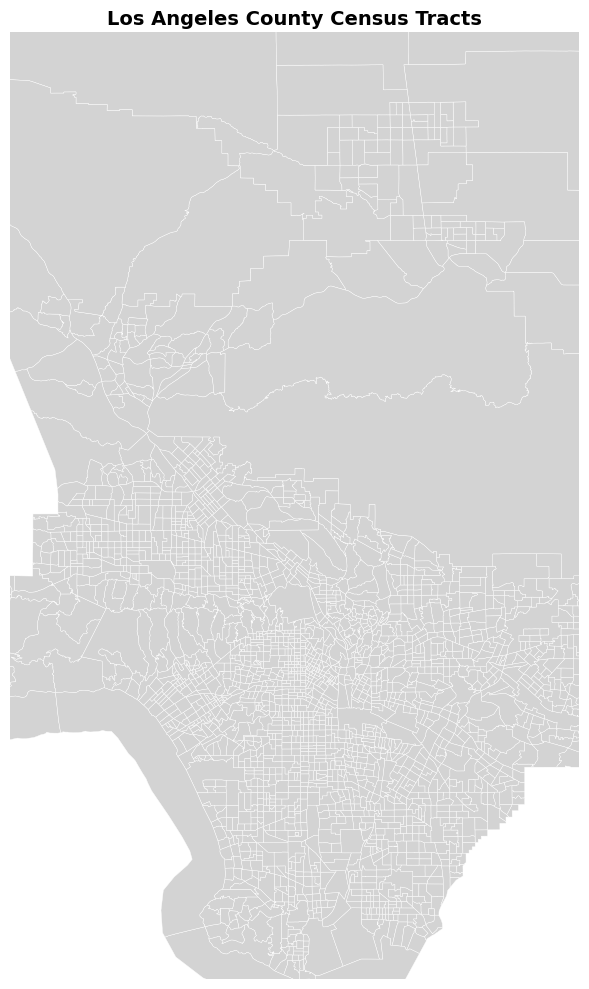

In [49]:
print("Creating maps...")

la_bbox = {
    'min_lon': -118.7,
    'max_lon': -117.9,
    'min_lat': 33.7,
    'max_lat': 34.8
}

if 'tracts_with_data' in locals() and tracts_with_data is not None:
    tracts_map = tracts_with_data.to_crs(config.GEOGRAPHIC_CRS)
    tracts_map = tracts_map.cx[la_bbox['min_lon']:la_bbox['max_lon'], la_bbox['min_lat']:la_bbox['max_lat']]
    
    if 'stops' in locals() and stops is not None and len(stops) > 0:
        stops_map = stops.to_crs(config.GEOGRAPHIC_CRS)
        stops_map = stops_map.cx[la_bbox['min_lon']:la_bbox['max_lon'], la_bbox['min_lat']:la_bbox['max_lat']]
    else:
        stops_map = gpd.GeoDataFrame()  # Empty

    fig, ax = plt.subplots(figsize=(12, 10))
    tracts_map.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.3)
    ax.set_xlim(la_bbox['min_lon'], la_bbox['max_lon'])
    ax.set_ylim(la_bbox['min_lat'], la_bbox['max_lat'])
    ax.set_title('Los Angeles County Census Tracts', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(config.OUTPUTS_FIGURES / '00_tracts_base_map.png', dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: 00_tracts_base_map.png (LA County only)")
    plt.show()
else:
    print("  ⚠ Cannot create maps - tracts not loaded")


  ✓ Saved: 00_jobs_choropleth.png (LA County only)


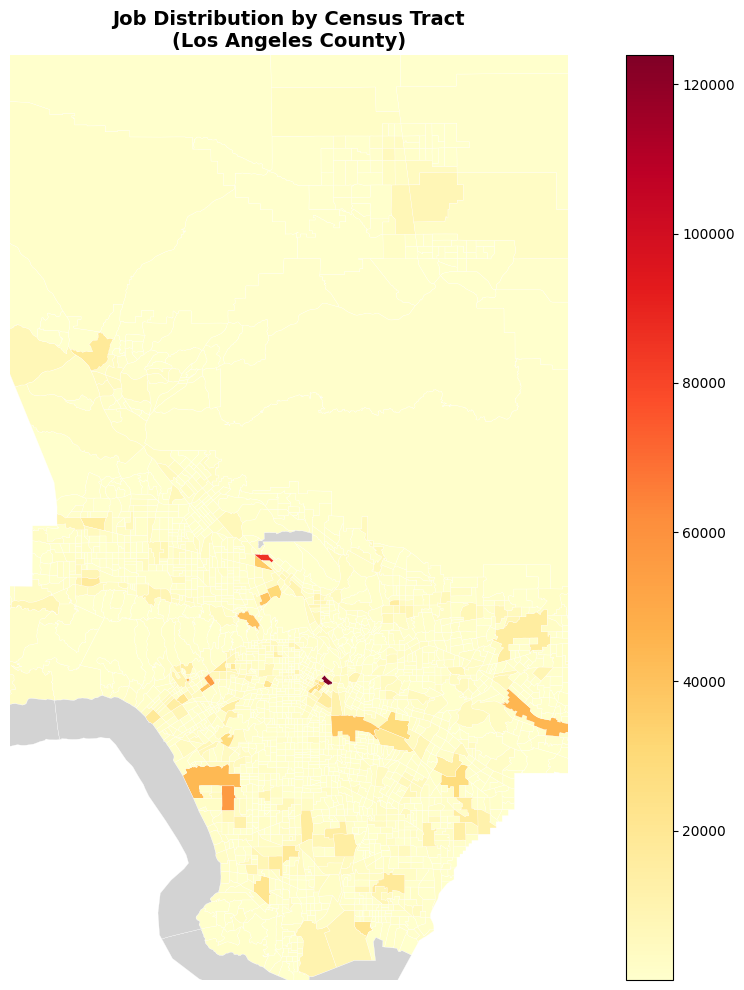

In [50]:
if 'tracts_map' in locals() and tracts_map is not None and 'jobs_total' in tracts_map.columns and tracts_map['jobs_total'].notna().any():
    fig, ax = plt.subplots(figsize=(12, 10))
    tracts_map.plot(
        column='jobs_total',
        ax=ax,
        legend=True,
        cmap='YlOrRd',
        edgecolor='white',
        linewidth=0.2,
        missing_kwds={'color': 'lightgray'}
    )
    ax.set_xlim(la_bbox['min_lon'], la_bbox['max_lon'])
    ax.set_ylim(la_bbox['min_lat'], la_bbox['max_lat'])
    ax.set_title('Job Distribution by Census Tract\n(Los Angeles County)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(config.OUTPUTS_FIGURES / '00_jobs_choropleth.png', dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: 00_jobs_choropleth.png (LA County only)")
    plt.show()
else:
    print("  ⚠ Skipping jobs map - no job data available")


  ✓ Saved: 00_transit_stops_overlay.png (LA County only)


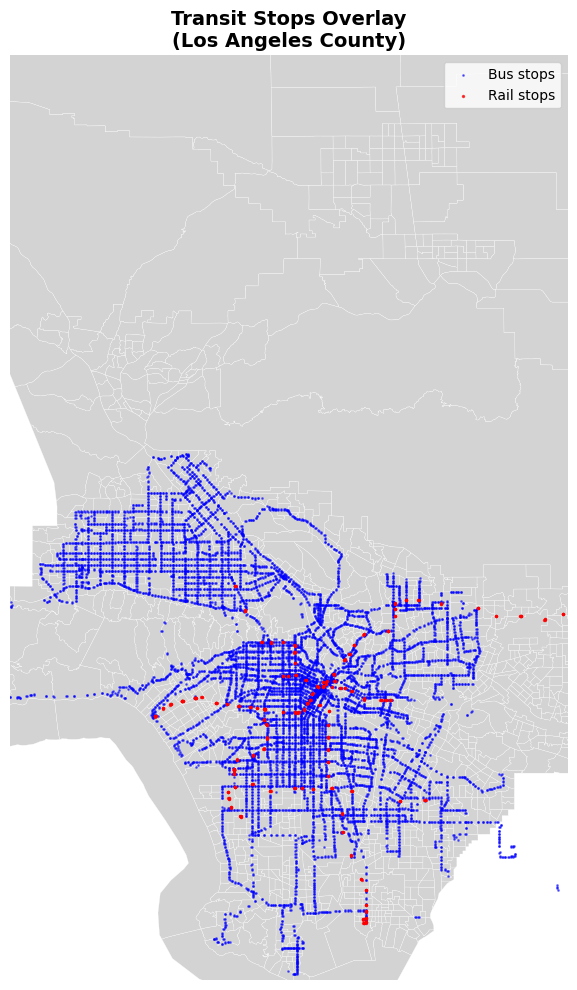

In [51]:
if 'tracts_map' in locals() and tracts_map is not None and 'stops_map' in locals() and len(stops_map) > 0:
    fig, ax = plt.subplots(figsize=(12, 10))
    tracts_map.plot(ax=ax, color='lightgray', edgecolor='white', linewidth=0.2)
    
    if 'mode' in stops_map.columns:
        bus_stops = stops_map[stops_map['mode'] == 'bus']
        rail_stops = stops_map[stops_map['mode'] == 'rail']
        
        if len(bus_stops) > 0:
            bus_stops.plot(ax=ax, color='blue', markersize=1, alpha=0.5, label='Bus stops')
        if len(rail_stops) > 0:
            rail_stops.plot(ax=ax, color='red', markersize=2, alpha=0.7, label='Rail stops')
    else:
        stops_map.plot(ax=ax, color='blue', markersize=1, alpha=0.5, label='Transit stops')
    
    ax.set_xlim(la_bbox['min_lon'], la_bbox['max_lon'])
    ax.set_ylim(la_bbox['min_lat'], la_bbox['max_lat'])
    ax.set_title('Transit Stops Overlay\n(Los Angeles County)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=11)
    ax.set_ylabel('Latitude', fontsize=11)
    ax.legend()
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(config.OUTPUTS_FIGURES / '00_transit_stops_overlay.png', dpi=300, bbox_inches='tight')
    print(f"  ✓ Saved: 00_transit_stops_overlay.png (LA County only)")
    plt.show()
else:
    print("  ⚠ Skipping transit stops map - no stops loaded or tracts not available")


## Part 7: Sanity Checks Summary

Final validation checklist.


In [52]:
print("=" * 80)
print("SANITY CHECKS SUMMARY")
print("=" * 80)

checks = {}

if 'tracts' in locals() and tracts is not None and len(tracts) > 0:
    checks["Census tracts loaded"] = True
    checks["Tract CRS consistent"] = tracts.crs is not None
    checks["Tract geometries valid"] = tracts.geometry.is_valid.all()
    bounds = tracts.total_bounds
    # LA County should be roughly: lon -118.7 to -117.9, lat 33.7 to 34.8
    checks["Tract bounding box reasonable"] = (bounds[0] > -120 and bounds[2] < -117 and bounds[1] > 33 and bounds[3] < 35)
else:
    checks["Census tracts loaded"] = False
    checks["Tract CRS consistent"] = False
    checks["Tract geometries valid"] = False
    checks["Tract bounding box reasonable"] = False

if 'tracts_with_data' in locals() and tracts_with_data is not None and 'jobs_total' in tracts_with_data.columns:
    checks["Job data loaded"] = tracts_with_data['jobs_total'].notna().any()
    if checks["Job data loaded"]:
        checks["Jobs are positive"] = not (tracts_with_data['jobs_total'] < 0).any()
    else:
        checks["Jobs are positive"] = False
else:
    checks["Job data loaded"] = False
    checks["Jobs are positive"] = False

if 'tracts_with_data' in locals() and tracts_with_data is not None and 'pop_total' in tracts_with_data.columns:
    checks["Population data available"] = tracts_with_data['pop_total'].notna().any()
else:
    checks["Population data available"] = False

if 'stops' in locals() and stops is not None and len(stops) > 0:
    checks["Transit stops loaded"] = True
    checks["Stops CRS consistent"] = stops.crs == config.GEOGRAPHIC_CRS
    if 'tracts' in locals() and tracts is not None:
        stop_bounds = stops.total_bounds
        tract_bounds = tracts.total_bounds
        overlap = not (stop_bounds[2] < tract_bounds[0] or stop_bounds[0] > tract_bounds[2] or
                       stop_bounds[3] < tract_bounds[1] or stop_bounds[1] > tract_bounds[3])
        checks["Spatial alignment"] = overlap
    else:
        checks["Spatial alignment"] = False
else:
    checks["Transit stops loaded"] = False
    checks["Stops CRS consistent"] = False
    checks["Spatial alignment"] = False

for check, passed in checks.items():
    status = "✓" if passed else "✗"
    print(f"{status} {check}")

all_passed = all(checks.values())
print("\n" + "=" * 80)
if all_passed:
    print("✓ ALL CHECKS PASSED - Data looks good!")
    print("\nCheckpoint: 'Yes, the data makes sense spatially, and nothing looks broken.'")
    print("\nNext: Proceed to Notebook 01 (Baseline Accessibility)")
else:
    print("⚠ SOME CHECKS FAILED - Review issues above before proceeding")
    print("\nAction: Fix data ingestion issues before continuing")
print("=" * 80)


SANITY CHECKS SUMMARY
✓ Census tracts loaded
✓ Tract CRS consistent
✓ Tract geometries valid
✗ Tract bounding box reasonable
✓ Job data loaded
✓ Jobs are positive
✓ Population data available
✓ Transit stops loaded
✓ Stops CRS consistent
✓ Spatial alignment

⚠ SOME CHECKS FAILED - Review issues above before proceeding

Action: Fix data ingestion issues before continuing


## Summary

**This notebook is READ-ONLY exploration. It does NOT:**
- ❌ Compute accessibility
- ❌ Calculate travel times
- ❌ Perform optimization
- ❌ Generate corridors

**It ONLY:**
- ✅ Loads raw data
- ✅ Performs sanity checks
- ✅ Creates simple maps
- ✅ Validates spatial alignment

**If all checks pass, proceed to Notebook 01.**


### 1.3 Load Demographics (Census ACS)


In [53]:
print("Loading demographics (Census ACS)...")
acs_files = list(config.DATA_RAW.glob("*acs*.csv"))
if acs_files:
    try:
        acs = pd.read_csv(acs_files[0])
        print(f"✓ Loaded ACS data")
        print(f"  Rows: {len(acs):,}")
        print(f"  Columns: {list(acs.columns)}")
        key_vars = ['population', 'income', 'pop_total', 'median_income']
        found_vars = [v for v in key_vars if v in acs.columns]
        if found_vars:
            print(f"  Key variables found: {found_vars}")
    except Exception as e:
        print(f"⚠ Error loading ACS: {e}")
        acs = None
else:
    print("⚠ No ACS files found")
    acs = None


Loading demographics (Census ACS)...
✓ Loaded ACS data
  Rows: 2,498
  Columns: ['NAME', 'B01003_001E', 'B19013_001E', 'B25046_001E', 'B08126_001E', 'B08301_001E', 'state', 'county', 'tract']


### 1.4 Load Transit Stops (GTFS)


In [54]:
print("Loading transit stops (GTFS)...")
try:
    from src.ingest import gtfs
    
    gtfs_feeds = gtfs.load_gtfs_feeds(config.DATA_RAW)
    if gtfs_feeds:
        stops = gtfs.extract_stops(gtfs_feeds)
        print(f"✓ Loaded transit stops")
        print(f"  Total stops: {len(stops):,}")
        if 'mode' in stops.columns:
            print(f"  Bus stops: {(stops['mode'] == 'bus').sum():,}")
            print(f"  Rail stops: {(stops['mode'] == 'rail').sum():,}")
        print(f"  CRS: {stops.crs}")
        print(f"  Bounds: {stops.total_bounds}")
    else:
        print("⚠ No GTFS feeds found")
        stops = None
except Exception as e:
    print(f"⚠ Error loading GTFS: {e}")
    stops = None


Loading transit stops (GTFS)...
⚠ Error loading GTFS: No module named 'src'


## Part 2: Basic Sanity Checks

Perform fundamental data quality checks without any analysis.


In [55]:
print("=" * 80)
print("SANITY CHECKS")
print("=" * 80)

if tracts is not None:
    print(f"\n✓ Census Tracts:")
    print(f"  Total tracts: {len(tracts):,}")
    print(f"  Valid geometries: {tracts.geometry.is_valid.sum():,}")
    print(f"  Invalid geometries: {(~tracts.geometry.is_valid).sum():,}")
    
    geoid_cols = [c for c in tracts.columns if 'geoid' in c.lower() or c == 'GEOID']
    if geoid_cols:
        geoid_col = geoid_cols[0]
        print(f"  GEOID column: {geoid_col}")
        print(f"  Unique GEOIDs: {tracts[geoid_col].nunique():,}")
        print(f"  Missing GEOIDs: {tracts[geoid_col].isna().sum():,}")
else:
    print("\n⚠ Tracts not loaded")

if jobs is not None:
    print(f"\n✓ Job Data:")
    print(f"  Total rows: {len(jobs):,}")
    job_cols = [c for c in jobs.columns if 'job' in c.lower() or 'c000' in c.lower() or 's000' in c.lower()]
    if job_cols:
        job_col = job_cols[0]
        total_jobs = jobs[job_col].sum()
        print(f"  Total jobs: {total_jobs:,.0f}")
        print(f"  Tracts with jobs: {(jobs[job_col] > 0).sum():,}")
        print(f"  Tracts with zero jobs: {(jobs[job_col] == 0).sum():,}")
        print(f"  Missing job data: {jobs[job_col].isna().sum():,}")
else:
    print("\n⚠ Jobs not loaded")

if acs is not None:
    print(f"\n✓ Demographics:")
    print(f"  Total rows: {len(acs):,}")
    pop_cols = [c for c in acs.columns if 'pop' in c.lower() or 'b01003' in c.lower()]
    if pop_cols:
        pop_col = pop_cols[0]
        total_pop = acs[pop_col].sum()
        print(f"  Total population: {total_pop:,.0f}")
        print(f"  Missing population: {acs[pop_col].isna().sum():,}")
else:
    print("\n⚠ Demographics not loaded")

if stops is not None:
    print(f"\n✓ Transit Stops:")
    print(f"  Total stops: {len(stops):,}")
    print(f"  Valid geometries: {stops.geometry.is_valid.sum():,}")
    print(f"  Invalid geometries: {(~stops.geometry.is_valid).sum():,}")
else:
    print("\n⚠ Transit stops not loaded")


SANITY CHECKS

✓ Census Tracts:
  Total tracts: 2,498
  Valid geometries: 2,498
  Invalid geometries: 0
  GEOID column: GEOID
  Unique GEOIDs: 2,498
  Missing GEOIDs: 0

✓ Job Data:
  Total rows: 2,494
  Total jobs: 4,478,164
  Tracts with jobs: 2,494
  Tracts with zero jobs: 0
  Missing job data: 0

✓ Demographics:
  Total rows: 2,498
  Total population: 9,936,690
  Missing population: 0

⚠ Transit stops not loaded


### 2.5 CRS Consistency Check


In [56]:
print("Checking CRS consistency...")
crs_status = {}

if tracts is not None:
    crs_status['tracts'] = str(tracts.crs)
    
if stops is not None:
    crs_status['stops'] = str(stops.crs)

print("\nCRS Summary:")
for dataset, crs in crs_status.items():
    print(f"  {dataset:15s}: {crs}")

if len(crs_status) > 1:
    unique_crs = set(crs_status.values())
    if len(unique_crs) == 1:
        print("\n✓ All datasets have consistent CRS")
    else:
        print(f"\n⚠ CRS mismatch detected: {unique_crs}")
        print("  Note: This is OK - we'll normalize in processing")


Checking CRS consistency...

CRS Summary:
  tracts         : EPSG:4269


## Summary

**Status**: Ready to proceed if:
- [ ] GTFS files present
- [ ] Census tract shapefile present  
- [ ] LEHD job data present
- [ ] All folders created

**Next**: Proceed to Notebook 01 (Baseline Accessibility)
